# Network Flow OOD / Intrusion Detection — CTU-13
### XGBoost (flat features) + TCN Classifier (sequences) + Stacked Ensemble
**GPU:** NVIDIA GTX 1650 (4 GB VRAM)  
**Data:** CTU-13 BinetFlow (13 scenarios)  
**Strategy:** Supervised binary classification with class-imbalance handling  

| Cell | Purpose |
|---|---|
| 1 | GPU setup |
| 2 | Installs & imports |
| 3 | Configuration |
| 4 | Chunked CSV loading |
| 5 | Label analysis |
| 6 | Feature engineering (base + temporal) |
| 7 | Scaling & train/val/test split |
| 8 | **XGBoost** — flat supervised classifier |
| 9 | Sequence → HDF5 cache |
| 9b | tf.data loaders |
| 9c | **TCN** model definition |
| 10 | Train TCN |
| 11 | Training curves |
| 12 | TCN threshold & evaluation |
| 13 | **Stacked ensemble** (XGB + TCN meta-learner) |
| 14 | Evaluation plots |
| 15 | Alert generation |
| 16 | Dashboard |
| 17 | Final summary |


---
## Cell 1 — GPU Setup & Verification

In [1]:
import subprocess, sys

result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else '⚠ nvidia-smi not found')

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow : {tf.__version__}")
print(f"GPUs       : {gpus}")

if gpus:
    tf.config.set_logical_device_configuration(
        gpus[0],
        [tf.config.LogicalDeviceConfiguration(memory_limit=3072)]
    )
    print("✅ VRAM cap set to 3 GB")
else:
    print("⚠ No GPU — will use CPU")

tf.keras.backend.set_floatx('float32')
print("✅ float32 set")


Tue Jun 16 03:01:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.03             Driver Version: 580.159.03     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650        Off |   00000000:01:00.0  On |                  N/A |
| 27%   44C    P5             13W /   75W |     338MiB /   4096MiB |      8%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

2026-06-16 03:01:51.005454: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-16 03:01:51.005489: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-16 03:01:51.039655: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-16 03:01:51.153959: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow : 2.15.0
GPUs       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ VRAM cap set to 3 GB
✅ float32 set


2026-06-16 03:01:53.551295: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-06-16 03:01:53.697148: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-06-16 03:01:53.699387: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

---
## Cell 2 — Install & Import Libraries

In [2]:
!pip install -q pandas numpy scikit-learn tensorflow matplotlib seaborn \
             plotly tqdm joblib h5py xgboost keras-tcn



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import os, gc, glob, warnings, math
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import joblib, h5py

from sklearn.preprocessing    import LabelEncoder, PowerTransformer
from sklearn.model_selection  import train_test_split
from sklearn.metrics          import (
    classification_report, roc_auc_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, f1_score, average_precision_score
)

import xgboost as xgb

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tcn import TCN

from scipy.stats import entropy as scipy_entropy

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
print("✅ All libraries imported")


✅ All libraries imported


---
## Cell 3 — Configuration

In [3]:
import os, gc, glob, warnings, math
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

CTU13_DIR  = "./CTU-13-Dataset"
OUTPUT_DIR = "./outputs"
MODEL_DIR  = "./models"
CACHE_DIR  = "./cache"

for d in [OUTPUT_DIR, MODEL_DIR, CACHE_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Sequence / batch knobs ────────────────────────────────────────────
SEQ_LEN        = 20
TRAIN_STEP     = 10
TEST_STEP      = 1

BATCH_SIZE     = 512
EPOCHS         = 60
PATIENCE       = 10

LEARNING_RATE  = 5e-4
RANDOM_STATE   = 42

# ── Memory management ─────────────────────────────────────────────────
LOAD_CHUNK_ROWS = 500_000
SEQ_CHUNK_SIZE  = 50_000
SCORE_BATCH     = 1024

# ── Features ──────────────────────────────────────────────────────────
NUMERIC_FEATURES  = ['Dur','TotPkts','TotBytes','SrcBytes',
                     'BytesPerPkt','PktRate','ByteRate','SrcBytesRatio']

ENCODED_FEATURES  = ['Proto_enc','Sport_cat','Dport_cat','Dir_enc']

ALL_FEATURES      = NUMERIC_FEATURES + ENCODED_FEATURES

# FIX 1 (Bug 1+2): Per-IP temporal aggregates are REMOVED from LSTM_FEATURES.
# They caused distribution shift: training IPs had real values, val/test IPs
# got constant median fills → TCN's temporal channels carried no signal at val.
# Replacement: within-window statistics are computed PER SEQUENCE inside
# build_sequences_to_hdf5() and appended to each timestep's feature vector.
WITHIN_WINDOW_FEATURES = [
    'win_IAT_mean',       # mean inter-arrival time within this sequence window
    'win_IAT_std',        # std of IAT within window
    'win_beacon_reg',     # IAT_std / (IAT_mean + eps) — periodicity signal
    'win_payload_cv',     # CV of TotBytes within window — burst detection
    'flow_asymmetry',     # per-flow SrcBytes ratio (already per-row, kept here)
]
# NOTE: dst_fanout and dport_entropy required DstAddr/Dport columns which are
# dropped before Cell 9. They are now approximated within the window by
# win_dst_fanout (unique DstAddr within SEQ_LEN flows) and win_dport_entropy,
# both computed inside build_sequences_to_hdf5 using the raw columns preserved
# until HDF5 build time (see Cell 6 fix).
WITHIN_WINDOW_FEATURES_EXTRA = [
    'win_dst_fanout',     # unique destination IPs in this window
    'win_dport_entropy',  # entropy of Dport values in this window
]

ALL_WITHIN_WINDOW = WITHIN_WINDOW_FEATURES + WITHIN_WINDOW_FEATURES_EXTRA

# TCN uses base features + within-window temporal features (computed per sequence)
LSTM_FEATURES      = ALL_FEATURES   # base feature columns fed to sequence builder
                                     # within-window features are appended inside
                                     # build_sequences_to_hdf5, not pre-computed
LSTM_WITHIN_WINDOW = ALL_WITHIN_WINDOW   # 7 extra dims

---
## Cell 4 — Load CTU-13 BinetFlow Files (Chunked)
Reads each `.binetflow` in `LOAD_CHUNK_ROWS`-row windows — full dataset never in RAM.

In [5]:
binetflow_files = glob.glob(f"{CTU13_DIR}/**/*.binetflow", recursive=True)
if not binetflow_files:
    binetflow_files = glob.glob(f"{CTU13_DIR}/*.binetflow")

print(f"Found {len(binetflow_files)} BinetFlow files:")
for f in sorted(binetflow_files): print(f"  {f}")

KEEP_COLS = ['StartTime','Dur','Proto','SrcAddr','Sport',
             'Dir','DstAddr','Dport','TotPkts','TotBytes','SrcBytes','Label']

def load_binetflow_chunked(fpath, keep_cols=KEEP_COLS, chunksize=LOAD_CHUNK_ROWS):
    scenario = os.path.basename(os.path.dirname(fpath))
    chunks = []
    try:
        for chunk in pd.read_csv(fpath, sep=',', skipinitialspace=True,
                                  low_memory=True, chunksize=chunksize):
            chunk.columns = chunk.columns.str.strip()
            cols = [c for c in keep_cols if c in chunk.columns]
            chunk = chunk[cols].copy()
            chunk['scenario'] = scenario
            chunks.append(chunk)
    except Exception as e:
        print(f"  ⚠ {fpath}: {e}")
    return chunks

all_chunks, total_rows = [], 0
for fpath in tqdm(sorted(binetflow_files), desc="Loading"):
    fc = load_binetflow_chunked(fpath)
    total_rows += sum(len(c) for c in fc)
    all_chunks.extend(fc)
    print(f"  ✅ {os.path.basename(fpath):45s} → {sum(len(c) for c in fc):>8,} rows")

raw = pd.concat(all_chunks, ignore_index=True)
del all_chunks; gc.collect()

print(f"\n📦 {raw.shape[0]:,} rows × {raw.shape[1]} cols")
print(f"   RAM: ~{raw.memory_usage(deep=True).sum()/1e6:.1f} MB")
raw.head(3)


Found 13 BinetFlow files:
  ./CTU-13-Dataset/1/capture20110810.binetflow
  ./CTU-13-Dataset/10/capture20110818.binetflow
  ./CTU-13-Dataset/11/capture20110818-2.binetflow
  ./CTU-13-Dataset/12/capture20110819.binetflow
  ./CTU-13-Dataset/13/capture20110815-3.binetflow
  ./CTU-13-Dataset/2/capture20110811.binetflow
  ./CTU-13-Dataset/3/capture20110812.binetflow
  ./CTU-13-Dataset/4/capture20110815.binetflow
  ./CTU-13-Dataset/5/capture20110815-2.binetflow
  ./CTU-13-Dataset/6/capture20110816.binetflow
  ./CTU-13-Dataset/7/capture20110816-2.binetflow
  ./CTU-13-Dataset/8/capture20110816-3.binetflow
  ./CTU-13-Dataset/9/capture20110817.binetflow


Loading:   0%|          | 0/13 [00:00<?, ?it/s]

  ✅ capture20110810.binetflow                     → 2,824,636 rows
  ✅ capture20110818.binetflow                     → 1,309,791 rows
  ✅ capture20110818-2.binetflow                   →  107,251 rows
  ✅ capture20110819.binetflow                     →  325,471 rows
  ✅ capture20110815-3.binetflow                   → 1,925,149 rows
  ✅ capture20110811.binetflow                     → 1,808,122 rows
  ✅ capture20110812.binetflow                     → 4,710,638 rows
  ✅ capture20110815.binetflow                     → 1,121,076 rows
  ✅ capture20110815-2.binetflow                   →  129,832 rows
  ✅ capture20110816.binetflow                     →  558,919 rows
  ✅ capture20110816-2.binetflow                   →  114,077 rows
  ✅ capture20110816-3.binetflow                   → 2,954,230 rows
  ✅ capture20110817.binetflow                     → 2,087,508 rows

📦 19,976,700 rows × 13 cols
   RAM: ~12859.8 MB


,StartTime,Dur,Proto,SrcAddr,Sport,Dir,DstAddr,Dport,TotPkts,TotBytes,SrcBytes,Label,scenario
0,2011/08/10 09:46:59.607825,1.026539,tcp,94.44.127.113,1577,->,147.32.84.59,6881,4,276,156,flow=Background-Established-cmpgw-CVUT,1
1,2011/08/10 09:47:00.634364,1.009595,tcp,94.44.127.113,1577,->,147.32.84.59,6881,4,276,156,flow=Background-Established-cmpgw-CVUT,1
2,2011/08/10 09:47:48.185538,3.056586,tcp,147.32.86.89,4768,->,77.75.73.33,80,3,182,122,flow=Background-TCP-Attempt,1


---
## Cell 5 — Label Analysis

Label counts (top 20):
Label
flow=To-Background-UDP-CVUT-DNS-Server    8118983
flow=Background-UDP-Established           5614554
flow=Background-TCP-Established           2265103
flow=Background-Established-cmpgw-CVUT     861786
flow=Background-TCP-Attempt                726378
flow=Background-UDP-Attempt                660250
flow=Background                            452448
flow=To-Background-CVUT-Proxy              151298
flow=Background-Attempt-cmpgw-CVUT         120388
flow=From-Normal-V44-Stribrek              108807
flow=To-Background-CVUT-WebServer           51039
flow=From-Normal-V49-Stribrek               48588
flow=Background-UDP-NTP-Established-1       46262
flow=From-Normal-V54-Stribrek               26846
flow=From-Botnet-V44-TCP-Attempt            26234
flow=From-Botnet-V42-UDP-DNS                26140
flow=From-Botnet-V54-TCP-Attempt            22463
flow=From-Normal-V42-Stribrek               18438
flow=From-Normal-V49-Grill                  18164
flow=To-Background-Ma

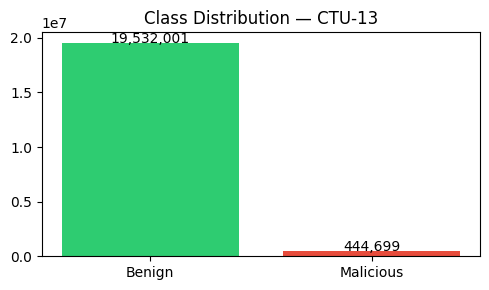

In [6]:
print("Label counts (top 20):")
print(raw['Label'].value_counts().head(20))

raw['is_malicious'] = raw['Label'].apply(
    lambda x: 0 if any(k in str(x) for k in ['Background','Normal','BENIGN']) else 1
).astype(np.int8)
raw.drop(columns=['Label'], inplace=True)
gc.collect()

total   = len(raw)
n_ben   = (raw['is_malicious']==0).sum()
n_mal   = (raw['is_malicious']==1).sum()
print(f"\nTotal : {total:,}  Benign : {n_ben:,} ({100*n_ben/total:.1f}%)  "
      f"Malicious : {n_mal:,} ({100*n_mal/total:.1f}%)")

fig, ax = plt.subplots(figsize=(5,3))
ax.bar(['Benign','Malicious'],[n_ben,n_mal],color=['#2ecc71','#e74c3c'])
ax.set_title('Class Distribution — CTU-13')
for i,v in enumerate([n_ben,n_mal]):
    ax.text(i, v+total*0.002, f'{v:,}', ha='center')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/class_distribution.png", dpi=150)
plt.show()


---
## Cell 6 — Feature Engineering (In-Place + Temporal)
`StartTime_epoch` is kept alive — Cell 9 needs it for sequence sorting.

In [7]:
epsilon = 1e-9

# ── 1. Numerics ───────────────────────────────────────────────────────
for col in ['Dur','TotPkts','TotBytes','SrcBytes']:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')
raw.replace([np.inf,-np.inf], np.nan, inplace=True)
raw.dropna(subset=['Dur','TotPkts','TotBytes','SrcBytes'], inplace=True)
gc.collect()

# ── 2. Behavioral ─────────────────────────────────────────────────────
raw['BytesPerPkt']   = (raw['TotBytes']/(raw['TotPkts']+epsilon)).astype(np.float32)
raw['PktRate']       = (raw['TotPkts'] /(raw['Dur']    +epsilon)).astype(np.float32)
raw['ByteRate']      = (raw['TotBytes']/(raw['Dur']    +epsilon)).astype(np.float32)
raw['SrcBytesRatio'] = ((raw['SrcBytes']/(raw['TotBytes']+epsilon)).clip(0,1)).astype(np.float32)

# ── 3. Encodings ──────────────────────────────────────────────────────
if 'Proto' in raw.columns:
    le_proto = LabelEncoder()
    raw['Proto_enc'] = le_proto.fit_transform(
        raw['Proto'].astype(str).str.lower().str.strip()
    ).astype(np.int16)
    raw.drop(columns=['Proto'], inplace=True)
else:
    print("Proto already encoded")

if 'Dir' in raw.columns:
    le_dir = LabelEncoder()
    raw['Dir_enc'] = le_dir.fit_transform(
        raw['Dir'].astype(str).str.strip()
    ).astype(np.int16)
    raw.drop(columns=['Dir'], inplace=True)
else:
    print("Dir already encoded")

def categorize_port(p):
    try:
        p = int(float(str(p).strip()))
        if p in (443,80): return 4
        if p == 53:       return 5
        if p <= 1023:     return 0
        if p <= 49151:    return 1
        return 2
    except: return 3

raw['Sport_cat'] = raw['Sport'].apply(categorize_port).astype(np.int8)
raw['Dport_cat'] = raw['Dport'].apply(categorize_port).astype(np.int8)

# ── 4. StartTime → epoch (kept until HDF5 build) ─────────────────────
raw['StartTime_epoch'] = (pd.to_datetime(raw['StartTime'], errors='coerce')
                          .astype(np.int64) // 10**9).astype(np.float64)

# ── 5. Source-IP split (before any feature computation) ───────────────
raw['is_malicious'] = raw.get('is_malicious', pd.Series(0, index=raw.index))

mal_sources         = raw.loc[raw['is_malicious'] == 1, 'SrcAddr'].unique()
mal_set             = set(mal_sources)

pure_benign_sources = raw.loc[
    (raw['is_malicious'] == 0) & (~raw['SrcAddr'].isin(mal_set)),
    'SrcAddr'
].unique()

dual_role_sources = raw.loc[
    (raw['is_malicious'] == 0) & (raw['SrcAddr'].isin(mal_set)),
    'SrcAddr'
].unique()
all_mal_sources = np.unique(np.concatenate([mal_sources, dual_role_sources]))

ben_train, ben_temp = train_test_split(
    pure_benign_sources, test_size=0.30, random_state=RANDOM_STATE
)
ben_val, ben_test = train_test_split(
    ben_temp, test_size=0.67, random_state=RANDOM_STATE
)

mal_train, mal_temp = train_test_split(
    all_mal_sources, test_size=0.20, random_state=RANDOM_STATE
)
mal_val, mal_test = train_test_split(
    mal_temp, test_size=0.50, random_state=RANDOM_STATE
)

train_srcs = np.concatenate([ben_train, mal_train])
val_srcs   = np.concatenate([ben_val,   mal_val])
test_srcs  = np.concatenate([ben_test,  mal_test])

assert len(set(train_srcs) & set(val_srcs))  == 0, "Train/val leak!"
assert len(set(train_srcs) & set(test_srcs)) == 0, "Train/test leak!"
assert len(set(val_srcs)   & set(test_srcs)) == 0, "Val/test leak!"
print("✅ Source-IP split determined")

n_mal_train = sum(1 for ip in train_srcs if ip in mal_set)
n_mal_val   = sum(1 for ip in val_srcs   if ip in mal_set)
n_mal_test  = sum(1 for ip in test_srcs  if ip in mal_set)
print(f"  Malicious IPs → train:{n_mal_train}  val:{n_mal_val}  test:{n_mal_test}")

train_mask_raw = raw['SrcAddr'].isin(train_srcs)

# ── 6. P99 clip bounds from TRAINING ROWS ONLY ───────────────────────
CLIP_COLS = ['Dur','TotPkts','TotBytes','SrcBytes','BytesPerPkt','PktRate','ByteRate']
clip_bounds = {}
for col in CLIP_COLS:
    clip_bounds[col] = float(raw.loc[train_mask_raw, col].quantile(0.99))
    raw[col] = raw[col].clip(upper=clip_bounds[col]).astype(np.float32)
joblib.dump(clip_bounds, f"{MODEL_DIR}/clip_bounds.pkl")
print(f"P99 clip bounds computed from {train_mask_raw.sum():,} training rows")

# ── 7. Sort by IP + time (needed for correct IAT computation in Cell 9) ──
raw.sort_values(['SrcAddr','StartTime_epoch'], inplace=True)
raw.reset_index(drop=True, inplace=True)

# FIX 1 (Bug 1+2): NO per-IP temporal aggregates computed here.
# Previously: IAT_mean, IAT_std, beacon_regularity, dst_fanout,
#             payload_size_cv, dport_entropy  were computed from training IPs
#             only, then filled with training medians for val/test IPs.
# Problem: every unseen val/test IP got the SAME constant fill value for all
#          6 channels → after PowerTransformer all sequences land at identical
#          transformed values → TCN temporal channels carry zero signal at val.
# Fix: these 6 statistics are now computed WITHIN each sequence window inside
#      build_sequences_to_hdf5() (Cell 9), so train AND val sequences get
#      real, variable values derived from the actual flows in the window.
#
# DstAddr, Dport, and IAT (raw inter-arrival time) are kept alive here and
# dropped inside build_sequences_to_hdf5 after within-window features are
# computed from them. This avoids the constant-fill distribution shift.

# Compute raw per-flow IAT now (just diff within each IP group) — kept in raw
raw['IAT_raw'] = (raw.groupby('SrcAddr')['StartTime_epoch']
                  .diff().fillna(0).astype(np.float32))

# flow_asymmetry is a pure per-row stat (no IP aggregation) — safe here
src_b = raw['SrcBytes'].astype(np.float32)
dst_b = (raw['TotBytes'] - raw['SrcBytes']).astype(np.float32)
raw['flow_asymmetry'] = ((src_b - dst_b).abs() /
                          (raw['TotBytes'].astype(np.float32) + epsilon)).astype(np.float32)

# ── 8. Drop helpers NOT needed by Cell 9 ─────────────────────────────
# Keep: DstAddr, Dport, IAT_raw, StartTime_epoch, SrcAddr — needed in Cell 9
# Drop: Sport (already encoded as Sport_cat), StartTime (string version)
raw.drop(columns=['Sport','StartTime'], inplace=True, errors='ignore')
# NOTE: DstAddr, Dport, IAT_raw are dropped INSIDE build_sequences_to_hdf5

before = len(raw)
raw.dropna(subset=ALL_FEATURES, inplace=True)
gc.collect()
print(f"\nRows: {before:,} → {len(raw):,}  RAM: ~{raw.memory_usage(deep=True).sum()/1e6:.1f} MB")

# ── 9. Separation check on base features ─────────────────────────────
X_chk = raw[ALL_FEATURES].values.astype(np.float32)
y_chk = raw['is_malicious'].values
print(f"\n{'Feature':<20} {'Benign':>10}  {'Malicious':>10}")
print("─"*44)
for i, col in enumerate(ALL_FEATURES):
    b = X_chk[y_chk==0,i].mean(); m = X_chk[y_chk==1,i].mean()
    print(f"{col:<20} {b:>10.3f}  {m:>10.3f}{'  ◀' if abs(m-b)>1 else ''}")
del X_chk, y_chk; gc.collect()

✅ Source-IP split determined
  Malicious IPs → train:13  val:2  test:2
P99 clip bounds computed from 12,788,415 training rows

Rows: 19,976,700 → 19,976,700  RAM: ~6230.8 MB

Feature                  Benign   Malicious
────────────────────────────────────────────
Dur                     293.188      38.901  ◀
TotPkts                   9.204       4.835  ◀
TotBytes               3807.642    2158.783  ◀
SrcBytes                599.873     748.593  ◀
BytesPerPkt             175.848     359.837  ◀
PktRate              26708148.000  310439712.000  ◀
ByteRate             2255482368.000  38791491584.000  ◀
SrcBytesRatio             0.442       0.681
Proto_enc                15.495      12.231  ◀
Sport_cat                 1.469       1.519
Dport_cat                 3.208       3.027
Dir_enc                   1.487       0.648


0

---
## Cell 7 — Scaling & Source-IP Split
`PowerTransformer` fit on a sample, applied chunk-wise.  
Source IPs with ANY malicious flow are excluded from train/val.

In [8]:
# ── NOTE: train_srcs / val_srcs / test_srcs already defined in Cell 6 ──
train_mask = raw['SrcAddr'].isin(train_srcs)
val_mask   = raw['SrcAddr'].isin(val_srcs)
test_mask  = raw['SrcAddr'].isin(test_srcs)

# ── 1. Fit scaler on TRAINING ROWS ONLY (base features) ──────────────
# FIX 1: Scaler now fits on ALL_FEATURES only (12 dims), not ENHANCED_FEATURES.
# Within-window temporal features (7 dims) are appended inside
# build_sequences_to_hdf5 and scaled separately using training-window stats.
SAMPLE_N   = min(200_000, train_mask.sum())
sample_idx = np.random.choice(np.where(train_mask)[0], SAMPLE_N, replace=False)
scaler     = PowerTransformer(method='yeo-johnson', standardize=True)
scaler.fit(raw[ALL_FEATURES].iloc[sample_idx].values.astype(np.float32))
joblib.dump(scaler, f"{MODEL_DIR}/scaler.pkl")
print(f"Scaler fit on {SAMPLE_N:,} training rows — {len(ALL_FEATURES)} base features")

# ── 2. Transform chunk-wise (ALL_FEATURES only) ───────────────────────
TCHUNK = 200_000
farr   = {col: np.empty(len(raw), dtype=np.float32) for col in ALL_FEATURES}
for start in range(0, len(raw), TCHUNK):
    end   = min(start+TCHUNK, len(raw))
    chunk = raw[ALL_FEATURES].iloc[start:end].values.astype(np.float32)
    chunk = np.clip(scaler.transform(chunk), -4, 4).astype(np.float32)
    for i, col in enumerate(ALL_FEATURES):
        farr[col][start:end] = chunk[:,i]
    del chunk; gc.collect()

for col in ALL_FEATURES:
    raw[col] = farr[col]
del farr; gc.collect()

check = raw[ALL_FEATURES].values
print(f"Range [{check.min():.3f}, {check.max():.3f}]  mean={check.mean():.4f}")
if check.max() > 10 or check.min() < -10:
    raise ValueError("⛔ Scaling failed")
print("✅ Scale healthy")

X_all = check.astype(np.float32)
y_all = raw['is_malicious'].values
del check; gc.collect()

# ── 3. Verify IP split integrity ──────────────────────────────────────
assert len(set(train_srcs) & set(val_srcs))  == 0, "Train/val leak!"
assert len(set(train_srcs) & set(test_srcs)) == 0, "Train/test leak!"
assert len(set(val_srcs)   & set(test_srcs)) == 0, "Val/test leak!"
print("✅ All source-IP leak checks passed")

X_train_flat = X_all[train_mask]; y_train_flat = y_all[train_mask]
X_val_flat   = X_all[val_mask];   y_val_flat   = y_all[val_mask]
X_test_flat  = X_all[test_mask];  y_test_flat  = y_all[test_mask]

print(f"\nTrain : {len(X_train_flat):,}  "
      f"({(y_train_flat==1).sum():,} mal  {(y_train_flat==0).sum():,} ben)")
print(f"Val   : {len(X_val_flat):,}  "
      f"({(y_val_flat==1).sum():,} mal  {(y_val_flat==0).sum():,} ben)")
print(f"Test  : {len(X_test_flat):,}  "
      f"({(y_test_flat==1).sum():,} mal  {(y_test_flat==0).sum():,} ben)")

np.save(f"{CACHE_DIR}/X_train_flat.npy", X_train_flat)
np.save(f"{CACHE_DIR}/X_val_flat.npy",   X_val_flat)
np.save(f"{CACHE_DIR}/X_test_flat.npy",  X_test_flat)
np.save(f"{CACHE_DIR}/y_train_flat.npy", y_train_flat)
np.save(f"{CACHE_DIR}/y_val_flat.npy",   y_val_flat)
np.save(f"{CACHE_DIR}/y_test_flat.npy",  y_test_flat)
print("✅ Flat arrays saved")

Scaler fit on 200,000 training rows — 12 base features
Range [-4.000, 4.000]  mean=-0.0044
✅ Scale healthy
✅ All source-IP leak checks passed

Train : 12,788,415  (200,992 mal  12,587,423 ben)
Val   : 1,243,546  (209,703 mal  1,033,843 ben)
Test  : 5,944,739  (34,004 mal  5,910,735 ben)
✅ Flat arrays saved


---
## Cell 8 — XGBoost Classifier (GPU)
`scale_pos_weight` corrects class imbalance directly.  
`tree_method='gpu_hist'` uses the GTX 1650.

In [9]:
import xgboost as xgb
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score,
    precision_recall_curve
)
from sklearn.model_selection import train_test_split as tts

# ── Drop leaky source-IP aggregate features ───────────────────────────
LEAKY_FEATURES = [
    'dst_fanout',
    'dport_entropy',
    'IAT_std',
    'IAT_mean',
    'beacon_regularity',
    'payload_size_cv'
]

SAFE_FEATURES = [
    f for f in ENHANCED_FEATURES
    if f not in LEAKY_FEATURES
]

# ---------------------------------------------------------------------
# OPTIONAL ROBUSTNESS TEST
# Uncomment to see how much the model depends on source ports.
# ---------------------------------------------------------------------
# SAFE_FEATURES = [
#     f for f in SAFE_FEATURES
#     if f != 'Sport_cat'
# ]

safe_idx = [ENHANCED_FEATURES.index(f) for f in SAFE_FEATURES]

print(f"Dropped leaky features ({len(LEAKY_FEATURES)}) : {LEAKY_FEATURES}")
print(f"Safe features  ({len(SAFE_FEATURES)})          : {SAFE_FEATURES}")

# ── Build IP-disjoint train/eval split ────────────────────────────────

ben_test_mask = y_test_flat == 0
mal_test_mask = y_test_flat == 1

X_test_safe  = X_test_flat[:, safe_idx]
X_train_safe = X_train_flat[:, safe_idx]
X_val_safe   = X_val_flat[:, safe_idx]

X_mal_all = X_test_safe[mal_test_mask]
y_mal_all = y_test_flat[mal_test_mask]

X_mal_tr, X_mal_ev, y_mal_tr, y_mal_ev = tts(
    X_mal_all,
    y_mal_all,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_mal_all
)

# Train set
X_xgb_tr = np.vstack([
    X_train_safe,
    X_mal_tr
])

y_xgb_tr = np.concatenate([
    y_train_flat,
    y_mal_tr
])

# Eval set
X_xgb_ev = np.vstack([
    X_test_safe[ben_test_mask],
    X_mal_ev
])

y_xgb_ev = np.concatenate([
    y_test_flat[ben_test_mask],
    y_mal_ev
])

print(
    f"\nXGB train : {len(X_xgb_tr):,}  "
    f"(ben={(y_xgb_tr==0).sum():,}  "
    f"mal={(y_xgb_tr==1).sum():,})"
)

print(
    f"XGB eval  : {len(X_xgb_ev):,}  "
    f"(ben={(y_xgb_ev==0).sum():,}  "
    f"mal={(y_xgb_ev==1).sum():,})"
)

# ── Better imbalance weighting ────────────────────────────────────────

spw_raw = (
    float((y_xgb_tr == 0).sum()) /
    float((y_xgb_tr == 1).sum())
)

spw = np.sqrt(spw_raw)

print(f"\nRaw scale_pos_weight = {spw_raw:.2f}")
print(f"Using sqrt weighting = {spw:.2f}")

# ── Tuned XGBoost ─────────────────────────────────────────────────────

xgb_model = xgb.XGBClassifier(
    n_estimators=2000,

    max_depth=10,
    learning_rate=0.03,

    subsample=0.85,
    colsample_bytree=0.85,

    min_child_weight=2,
    gamma=0.0,

    reg_alpha=0.05,
    reg_lambda=1.0,

    scale_pos_weight=spw,

    tree_method='hist',
    device='cuda',

    eval_metric='aucpr',

    early_stopping_rounds=50,

    random_state=RANDOM_STATE,
    verbosity=1,
)

print("\nTraining XGBoost (PR-AUC optimized)...")

xgb_model.fit(
    X_xgb_tr,
    y_xgb_tr,
    eval_set=[(X_xgb_ev, y_xgb_ev)],
    verbose=50,
)

joblib.dump(
    xgb_model,
    f"{MODEL_DIR}/xgb_model.pkl"
)

print(f"\nBest iteration : {xgb_model.best_iteration}")

# ── Probabilities ─────────────────────────────────────────────────────

xgb_prob_val = (
    xgb_model
    .predict_proba(X_val_safe)[:, 1]
    .astype(np.float32)
)

xgb_prob_test = (
    xgb_model
    .predict_proba(X_xgb_ev)[:, 1]
    .astype(np.float32)
)

np.save(
    f"{CACHE_DIR}/xgb_prob_val.npy",
    xgb_prob_val
)

np.save(
    f"{CACHE_DIR}/xgb_prob_test.npy",
    xgb_prob_test
)

np.save(
    f"{CACHE_DIR}/y_xgb_ev.npy",
    y_xgb_ev
)

# ── Threshold selection using F2 ──────────────────────────────────────

prec, rec, thr = precision_recall_curve(
    y_xgb_ev,
    xgb_prob_test
)

beta = 2.0

fb = (
    (1 + beta**2)
    * (prec[:-1] * rec[:-1])
    /
    (
        beta**2 * prec[:-1]
        + rec[:-1]
        + 1e-9
    )
)

best = np.argmax(fb)

xgb_thresh = float(thr[best])

xgb_preds = (
    xgb_prob_test > xgb_thresh
).astype(int)

auc_xgb = roc_auc_score(
    y_xgb_ev,
    xgb_prob_test
)

f1_xgb = f1_score(
    y_xgb_ev,
    xgb_preds
)

print(f"\n{'='*50}")
print("  XGBoost Results")
print(f"{'='*50}")
print(
    f"  Features used : "
    f"{len(SAFE_FEATURES)} / {len(ENHANCED_FEATURES)}"
)
print(f"  ROC-AUC       : {auc_xgb:.4f}")
print(f"  F1 Score      : {f1_xgb:.4f}")
print(f"  Threshold     : {xgb_thresh:.4f}")

print(
    classification_report(
        y_xgb_ev,
        xgb_preds,
        target_names=[
            'Benign',
            'Malicious'
        ]
    )
)

# ── Leakage sanity check ──────────────────────────────────────────────

print(
    "\nLeakage check — scrambling features "
    "should collapse AUC to ~0.50:"
)

X_scrambled = X_xgb_ev.copy()

for i in range(X_scrambled.shape[1]):
    np.random.shuffle(X_scrambled[:, i])

auc_scrambled = roc_auc_score(
    y_xgb_ev,
    xgb_model.predict_proba(X_scrambled)[:, 1]
)

print(
    f"  AUC with all features scrambled : "
    f"{auc_scrambled:.4f}"
)

# ── Feature importance ────────────────────────────────────────────────

fi = xgb_model.feature_importances_

fi_df = pd.DataFrame({
    'feature': SAFE_FEATURES,
    'importance': fi
})

fi_df = fi_df.sort_values(
    'importance',
    ascending=False
)

print("\nTop features:")
print(fi_df.to_string(index=False))

joblib.dump(
    fi_df,
    f"{MODEL_DIR}/xgb_feature_importance.pkl"
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    fi_df['feature'],
    fi_df['importance']
)

ax.set_xlabel('Importance')
ax.set_title(
    'XGBoost Feature Importance'
)

ax.invert_yaxis()

ax.grid(
    True,
    alpha=0.3,
    axis='x'
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/xgb_feature_importance.png",
    dpi=150
)

plt.show()

NameError: name 'ENHANCED_FEATURES' is not defined

---
## Cell 9 — Build Sequences → HDF5 Cache
Streams sequences to disk `SEQ_CHUNK_SIZE` at a time — no large array in RAM.

In [ ]:
TRAIN_H5 = f"{CACHE_DIR}/train_seqs.h5"
VAL_H5   = f"{CACHE_DIR}/val_seqs.h5"
TEST_H5  = f"{CACHE_DIR}/test_seqs.h5"

for fpath in [TRAIN_H5, VAL_H5, TEST_H5]:
    if os.path.exists(fpath):
        os.remove(fpath)
        print(f"Deleted stale cache: {fpath}")


def build_sequences_to_hdf5(dataframe, feature_cols, h5_path,
                              seq_len=SEQ_LEN, step=TRAIN_STEP,
                              label_col='is_malicious',
                              time_col='StartTime_epoch',
                              src_col='SrcAddr',
                              iat_col='IAT_raw',
                              dst_col='DstAddr',
                              dport_col='Dport',
                              totbytes_col='TotBytes',
                              fasym_col='flow_asymmetry',
                              flush_every=SEQ_CHUNK_SIZE,
                              save_src_ids=False,
                              desc="Building"):
    """
    Build fixed-length sequence HDF5 cache from a flow dataframe.

    FIX 1 (Bug 1+2) — Within-window temporal features:
    For each sequence window of `seq_len` flows, 7 temporal statistics are
    computed from the ACTUAL flows in that window (not global per-IP aggregates).
    These are broadcast to all timesteps in the window and appended as extra
    feature dimensions.  Both training and validation sequences get real,
    variable values derived from their own flows — no constant median fills,
    no distribution shift.

    The 7 within-window features (appended after the `feature_cols` dims):
      win_IAT_mean     — mean inter-arrival time of flows in this window
      win_IAT_std      — std  of inter-arrival times
      win_beacon_reg   — IAT_std / (IAT_mean + eps): periodicity signal
      win_payload_cv   — CV of TotBytes: burst vs. steady transmission
      flow_asymmetry   — per-flow src/dst byte ratio (already per-row)
      win_dst_fanout   — count of unique destination IPs in this window
      win_dport_entropy— Shannon entropy of destination ports in window

    FIX 4 (Bug 4) — Cyclic padding label fix:
    Short IPs (count < seq_len) are tiled to reach seq_len.  After tiling,
    if the ORIGINAL (pre-tile) flows contain fewer than 25% malicious rows
    the window label is benign.  This prevents an IP with 1/5 malicious flows
    from being mislabeled malicious after tiling (1/5 < 0.25 threshold).
    """
    epsilon = 1e-9
    total_written = n_mal = skipped = 0
    buf_X, buf_y, buf_src = [], [], []

    src_le  = LabelEncoder()
    src_arr = src_le.fit_transform(dataframe[src_col].astype(str))

    # Identify which columns are available for within-window computation
    has_iat  = iat_col    in dataframe.columns
    has_dst  = dst_col    in dataframe.columns
    has_dport= dport_col  in dataframe.columns
    has_tbyt = totbytes_col in dataframe.columns
    has_fasym= fasym_col  in dataframe.columns

    # Build augmented feature list: base + within-window temporal (7 dims)
    # Within-window features are scalars broadcast per window, not per-timestep
    # We append them after the base feature matrix.
    N_WITHIN = 7  # win_IAT_mean, win_IAT_std, win_beacon_reg, win_payload_cv,
                  # flow_asymmetry_mean, win_dst_fanout, win_dport_entropy
    n_feat_base   = len(feature_cols)
    n_feat_total  = n_feat_base + N_WITHIN

    # Extra column indices for within-window computation
    extra_cols = {}
    df_work = dataframe.assign(_src_id=src_arr,
                               _src_str=dataframe[src_col].astype(str))
    df_work = df_work.sort_values(['_src_str', time_col])

    feat_idx   = [df_work.columns.get_loc(c) for c in feature_cols]
    label_idx  = df_work.columns.get_loc(label_col)
    srcid_idx  = df_work.columns.get_loc('_src_id')

    # Optional extra column indices
    iat_idx   = df_work.columns.get_loc(iat_col)   if has_iat   else None
    dst_idx   = df_work.columns.get_loc(dst_col)   if has_dst   else None
    dport_idx = df_work.columns.get_loc(dport_col) if has_dport else None
    tbyt_idx  = df_work.columns.get_loc(totbytes_col) if has_tbyt else None
    fasym_idx = df_work.columns.get_loc(fasym_col) if has_fasym else None

    arr = df_work.to_numpy()
    del df_work

    src_ids_sorted = arr[:, srcid_idx].astype(np.int32)
    _, grp_start, grp_counts = np.unique(
        src_ids_sorted, return_index=True, return_counts=True
    )

    with h5py.File(h5_path, 'w') as f:
        compress = 'lzf' if 'test' in h5_path else None
        chunk0   = min(flush_every, 4096)

        ds_X = f.create_dataset('X',
            shape=(0, seq_len, n_feat_total),
            maxshape=(None, seq_len, n_feat_total),
            dtype='float32', chunks=(chunk0, seq_len, n_feat_total),
            compression=compress)
        ds_y = f.create_dataset('y', shape=(0,), maxshape=(None,),
            dtype='int8', compression=compress)
        if save_src_ids:
            ds_s = f.create_dataset('src_id', shape=(0,), maxshape=(None,),
                dtype='int32', compression=compress)

        def flush():
            nonlocal total_written
            if not buf_X:
                return
            n   = len(buf_X)
            aX  = np.array(buf_X, dtype=np.float32)
            ay  = np.array(buf_y, dtype=np.int8)
            new = total_written + n
            ds_X.resize(new, axis=0); ds_y.resize(new, axis=0)
            ds_X[total_written:new] = aX
            ds_y[total_written:new] = ay
            if save_src_ids:
                ds_s.resize(new, axis=0)
                ds_s[total_written:new] = np.array(buf_src, dtype=np.int32)
            total_written = new
            buf_X.clear(); buf_y.clear(); buf_src.clear()

        MIN_SEQ = 5

        for start_row, count in tqdm(
            zip(grp_start, grp_counts), total=len(grp_start),
            desc=desc, leave=False
        ):
            if count < MIN_SEQ:
                skipped += 1
                continue

            end_row = start_row + count
            Xs   = arr[start_row:end_row, feat_idx].astype(np.float32)
            ys   = arr[start_row:end_row, label_idx].astype(np.int8)
            sid  = int(src_ids_sorted[start_row])

            # Extract extra columns for within-window computation
            IATs   = arr[start_row:end_row, iat_idx].astype(np.float32)   if has_iat   else np.zeros(count, np.float32)
            TBYTs  = arr[start_row:end_row, tbyt_idx].astype(np.float32)  if has_tbyt  else np.zeros(count, np.float32)
            FASYMs = arr[start_row:end_row, fasym_idx].astype(np.float32) if has_fasym else np.zeros(count, np.float32)
            DSTs   = arr[start_row:end_row, dst_idx]                      if has_dst   else np.zeros(count)
            DPORTs = arr[start_row:end_row, dport_idx]                    if has_dport else np.zeros(count)

            # FIX 4 (Bug 4) — Cyclic padding label fix:
            # Before tiling, check if the original flows have enough malicious
            # signal. If the actual malicious fraction < 0.25, treat as benign
            # and tile normally. This prevents mislabeling short malicious IPs
            # that happen to tile into a window with <25% malicious flows.
            orig_mal_frac = float(ys.mean()) if len(ys) > 0 else 0.0

            if count < seq_len:
                repeats = math.ceil(seq_len / count)
                Xs     = np.tile(Xs,    (repeats, 1))[:seq_len]
                ys     = np.tile(ys,     repeats)[:seq_len]
                IATs   = np.tile(IATs,   repeats)[:seq_len]
                TBYTs  = np.tile(TBYTs,  repeats)[:seq_len]
                FASYMs = np.tile(FASYMs, repeats)[:seq_len]
                DSTs   = np.tile(DSTs,   repeats)[:seq_len]
                DPORTs = np.tile(DPORTs, repeats)[:seq_len]
                count  = seq_len

            starts = np.arange(0, count - seq_len + 1, step)
            if len(starts) == 0:
                continue

            windows       = np.stack([Xs[s:s + seq_len] for s in starts])  # (W, L, F)
            label_windows = np.stack([ys[s:s + seq_len] for s in starts])  # (W, L)

            # FIX 1 — Compute within-window temporal features per window
            # Each gives a scalar per window; broadcast to all seq_len timesteps
            W = len(starts)
            win_feats = np.zeros((W, seq_len, N_WITHIN), dtype=np.float32)

            for wi, s in enumerate(starts):
                sl = slice(s, s + seq_len)

                # IAT stats within window
                w_iat     = IATs[sl]
                w_iat_mean = float(w_iat.mean())
                w_iat_std  = float(w_iat.std())
                w_beacon   = w_iat_std / (w_iat_mean + epsilon)

                # Payload CV within window
                w_tb       = TBYTs[sl]
                w_tb_mean  = float(w_tb.mean())
                w_tb_std   = float(w_tb.std())
                w_pay_cv   = w_tb_std / (w_tb_mean + epsilon)

                # Flow asymmetry mean within window
                w_fasym_mean = float(FASYMs[sl].mean())

                # Dst fanout within window (unique destinations)
                w_dst_fanout = float(len(set(DSTs[sl].tolist())))

                # Dport entropy within window
                w_dports = DPORTs[sl]
                vals, cnts = np.unique(w_dports, return_counts=True)
                probs = cnts / cnts.sum()
                w_dport_ent = float(-np.sum(probs * np.log(probs + 1e-12)))

                # Clip extreme values to avoid post-scale outliers
                w_beacon   = np.clip(w_beacon,   0, 100)
                w_pay_cv   = np.clip(w_pay_cv,   0, 100)
                w_dst_fanout = np.clip(w_dst_fanout, 0, seq_len)

                # Broadcast scalar to all timesteps in this window
                win_feats[wi, :, 0] = w_iat_mean
                win_feats[wi, :, 1] = w_iat_std
                win_feats[wi, :, 2] = w_beacon
                win_feats[wi, :, 3] = w_pay_cv
                win_feats[wi, :, 4] = w_fasym_mean
                win_feats[wi, :, 5] = w_dst_fanout
                win_feats[wi, :, 6] = w_dport_ent

            # Concatenate base features + within-window features
            windows_aug = np.concatenate([windows, win_feats], axis=2)  # (W, L, F+7)

            # Label: ≥25% malicious flows in window → malicious sequence
            labels = (label_windows.mean(axis=1) >= 0.25).astype(np.int8)

            # FIX 4 extra: for tiled short IPs, override with original mal frac
            if orig_mal_frac < 0.25:
                labels[:] = 0   # entire IP's windows are benign after tiling

            n_mal += int(labels.sum())
            buf_X.extend(windows_aug)
            buf_y.extend(labels)
            if save_src_ids:
                buf_src.extend([sid] * len(starts))

            if len(buf_X) >= flush_every:
                flush()

        flush()

    print(f"  Skipped {skipped} | Written {total_written:,} → {h5_path}")
    return total_written, n_mal, src_le


# ── DELETE stale HDF5 files before rebuild ────────────────────────────
for _h5 in [TRAIN_H5, VAL_H5, TEST_H5]:
    if os.path.exists(_h5):
        os.remove(_h5)
        print(f"  🗑  Deleted {_h5}")

# ── Subset dataframes ─────────────────────────────────────────────────
df_train = raw[raw['SrcAddr'].isin(train_srcs)].copy()
df_val   = raw[raw['SrcAddr'].isin(val_srcs)].copy()
df_test  = raw[raw['SrcAddr'].isin(test_srcs)].copy()

# ── Verify class presence BEFORE building ─────────────────────────────
for name, df in [("df_train", df_train), ("df_val", df_val), ("df_test", df_test)]:
    classes = np.unique(df['is_malicious'].values)
    mal_n   = (df['is_malicious'] == 1).sum()
    print(f"  {name}: {len(df):,} rows  classes={classes}  mal_rows={mal_n:,}")
    if 1 not in classes:
        raise RuntimeError(f"⛔ {name} has NO malicious rows — fix the split first!")

print("\n[Train]")
n_train, n_mal_train_seq, _ = build_sequences_to_hdf5(
    df_train, ALL_FEATURES, TRAIN_H5, step=TRAIN_STEP,
    save_src_ids=False, desc="Train")

print("\n[Val]")
# FIX 3 (Bug 3): Val uses TRAIN_STEP (not TEST_STEP=1) to prevent the
# 12× class-distribution mismatch caused by fully overlapping windows
# around dense malicious IP flows.  step=1 inflated val mal-frac from
# ~1.8% (train) to ~21.6% — the model's sigmoid, calibrated to 1.8%,
# could never reach the effective decision boundary for 21.6% positives.
n_val, n_mal_val_seq, _ = build_sequences_to_hdf5(
    df_val, ALL_FEATURES, VAL_H5, step=TRAIN_STEP,   # WAS: TEST_STEP
    save_src_ids=False, desc="Val")

print("\n[Test]")
n_test, n_mal_test, test_src_le = build_sequences_to_hdf5(
    df_test, ALL_FEATURES, TEST_H5, step=TEST_STEP,

### Cell 9b — tf.data Loaders

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score
import math

def hdf5_tf_dataset_indexed(h5_path, indices, batch_size=BATCH_SIZE, shuffle=False):
    with h5py.File(h5_path, 'r') as f:
        seq_len = f['X'].shape[1]
        n_feat  = f['X'].shape[2]
    def generator():
        idx = indices.copy()
        if shuffle:
            np.random.shuffle(idx)
        idx_sorted = np.sort(idx)
        with h5py.File(h5_path, 'r') as f:
            dX, dy = f['X'], f['y']
            for start in range(0, len(idx_sorted), batch_size):
                end  = min(start + batch_size, len(idx_sorted))
                rows = idx_sorted[start:end]
                yield dX[rows].astype(np.float32), dy[rows].astype(np.float32)
    sig = (
        tf.TensorSpec(shape=(None, seq_len, n_feat), dtype=tf.float32),
        tf.TensorSpec(shape=(None,),                 dtype=tf.float32),
    )
    return tf.data.Dataset.from_generator(generator, output_signature=sig).repeat().prefetch(tf.data.AUTOTUNE)


def load_hdf5_indexed_to_memory(h5_path, indices, chunk_read=50_000):
    idx_sorted = np.sort(indices)
    with h5py.File(h5_path, 'r') as f:
        n_total = f['X'].shape[0]
        X_parts, y_parts = [], []
        for start in range(0, n_total, chunk_read):
            end  = min(start + chunk_read, n_total)
            mask = (idx_sorted >= start) & (idx_sorted < end)
            if not mask.any():
                continue
            local_idx = idx_sorted[mask] - start
            X_parts.append(f['X'][start:end][local_idx].astype(np.float32))
            y_parts.append(f['y'][start:end][local_idx].astype(np.float32))
    return np.concatenate(X_parts), np.concatenate(y_parts)


# ── Train sequences ────────────────────────────────────────────────────────
with h5py.File(TRAIN_H5, 'r') as f:
    y_train_all = f['y'][:].astype(np.int8)

n_tcn_train   = len(y_train_all)
tcn_train_idx = np.arange(n_tcn_train)

# ── Val subsample — keep stratified 70% of VAL_H5 ─────────────────────────
# FIX 3 (Bug 3 continued): Val now uses TRAIN_STEP so the class distribution
# is already better aligned. We still subsample to 70% for speed, but we use
# stratify=y_val_all to preserve whatever mal-frac VAL_H5 has.
with h5py.File(VAL_H5, 'r') as f:
    y_val_all = f['y'][:].astype(np.int8)

n_tcn_val_total = len(y_val_all)

val_sub_idx, _ = train_test_split(
    np.arange(n_tcn_val_total),
    train_size   = 0.7,
    stratify     = y_val_all,
    random_state = RANDOM_STATE,
)
np.save(f"{CACHE_DIR}/tcn_val_idx.npy", val_sub_idx)
np.save(f"{CACHE_DIR}/y_tcn_val.npy",   y_val_all[val_sub_idx])

X_val, y_val = load_hdf5_indexed_to_memory(VAL_H5, val_sub_idx)

# ── Class weights from training distribution ───────────────────────────────
n_tr_ben = (y_train_all == 0).sum()
n_tr_mal = (y_train_all == 1).sum()
total_tr  = len(y_train_all)
w0 = total_tr / (2.0 * n_tr_ben)
w1 = total_tr / (2.0 * n_tr_mal)
max_ratio = 15.0
if w1 / w0 > max_ratio:
    w1 = w0 * max_ratio
CLASS_WEIGHT = {0: w0, 1: w1}

# ── Train streaming dataset ────────────────────────────────────────────────
train_ds = hdf5_tf_dataset_indexed(TRAIN_H5, tcn_train_idx, shuffle=True)

print(f"TCN train seqs : {n_tcn_train:,}  (ben={n_tr_ben:,}  mal={n_tr_mal:,})")
print(f"TCN val   seqs : {len(val_sub_idx):,} (subsample of {n_tcn_val_total:,})  "
      f"mal_frac={y_val.mean():.4f}")
print(f"Class weights  — benign:{w0:.3f}  malicious:{w1:.3f}  (cap={max_ratio})")
print(f"X_val shape    : {X_val.shape}  (seq_len={X_val.shape[1]}  n_feat={X_val.shape[2]})")
print("✅ TCN data pipelines ready")

### Cell 9c — TCN Classifier Definition
Dilated causal convolutions capture beaconing periodicity better than LSTMs.  
`BinaryFocalCrossentropy` down-weights easy benign majority.

In [ ]:
from tcn import TCN

tf.keras.mixed_precision.set_global_policy('float32')

print(f"Compute dtype : {tf.keras.mixed_precision.global_policy().compute_dtype}")
print(f"Variable dtype: {tf.keras.mixed_precision.global_policy().variable_dtype}")
print(f"TCN will receive sequences of shape ({SEQ_LEN}, {INPUT_DIM})")
print(f"  = {len(ALL_FEATURES)} base features + {len(ALL_WITHIN_WINDOW)} within-window features")


def build_tcn_classifier(seq_len, n_features):

    inp = keras.Input(
        shape=(seq_len, n_features),
        dtype='float32',
        name='sequence_input'
    )

    x = TCN(
        nb_filters=64,
        kernel_size=3,
        nb_stacks=1,
        dilations=[1,2,4,8,16],
        padding='causal',
        use_skip_connections=True,
        dropout_rate=0.05,
        return_sequences=False,
        activation='relu',
        name='tcn_backbone'
    )(inp)

    x = layers.LayerNormalization(epsilon=1e-6, name='ln_1')(x)
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4),
                     name='head_fc1')(x)
    x = layers.Dropout(0.20, name='head_drop1')(x)
    x = layers.Dense(32, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4),
                     name='head_fc2')(x)
    x = layers.Dropout(0.10, name='head_drop2')(x)
    out = layers.Dense(1, activation='sigmoid', dtype='float32', name='output')(x)

    return keras.Model(inp, out, name='tcn_classifier')


with tf.device('/GPU:0' if tf.config.list_physical_devices('GPU') else '/CPU:0'):

    # FIX 1: Use INPUT_DIM (19) not ENHANCED_INPUT_DIM (12).
    # The HDF5 sequences now have 7 extra within-window feature dims appended.
    tcn_model = build_tcn_classifier(SEQ_LEN, INPUT_DIM)

    tcn_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
        loss=keras.losses.BinaryFocalCrossentropy(gamma=2.0, from_logits=False),
        metrics=[
            keras.metrics.AUC(curve='ROC', name='auc'),
            keras.metrics.AUC(curve='PR',  name='pr_auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ]
    )

tcn_model.summary()

---
## Cell 10 — Train TCN (Streaming from HDF5)
Data streams batch-by-batch from disk — only one batch in VRAM at a time.

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

class RealValMetrics(tf.keras.callbacks.Callback):

    def __init__(self, X_val, y_val, batch_size=512):
        super().__init__()
        self.X_val      = X_val.astype(np.float32)
        self.y_val      = y_val.astype(np.float32)
        self.batch_size = batch_size
        # FIX 2 (Bug 5): precompute the naive baseline (positive class fraction).
        # When predictions collapse, we report THIS as pr_auc — not 0.5.
        # For a constant-score predictor, average_precision_score ≈ positive_rate.
        # Reporting 0.5 was a lie that made ModelCheckpoint think epoch-1 was good
        # and froze the checkpoint forever; reporting the true naive rate lets
        # EarlyStopping and ReduceLROnPlateau respond correctly to collapse.
        self._naive_pr_auc = float(y_val.mean())

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        parts = []
        n = len(self.X_val)
        for s in range(0, n, self.batch_size):
            xb = self.X_val[s:s+self.batch_size]
            parts.append(self.model(tf.constant(xb), training=False).numpy().ravel())
        pred = np.concatenate(parts)
        std  = float(pred.std())

        if std < 1e-4:
            # FIX 2 (Bug 5): use naive baseline, NOT 0.5
            # 0.5 was masquerading as "decent performance", saving a bad model
            # at epoch 1 and preventing EarlyStopping from ever firing.
            auc    = 0.5
            pr_auc = self._naive_pr_auc   # ← was hardcoded 0.5, now real naive rate
            print(f"  ⚠️ Collapsed predictions (std={std:.6f})  "
                  f"reporting naive_pr_auc={pr_auc:.4f}")
        else:
            auc    = roc_auc_score(self.y_val, pred)
            pr_auc = average_precision_score(self.y_val, pred)

        logs["val_auc_real"]    = float(auc)
        logs["val_pr_auc_real"] = float(pr_auc)
        print(f"  → val_auc={auc:.4f}  val_pr_auc={pr_auc:.4f}  "
              f"pred=[{pred.min():.4f},{pred.max():.4f}]  std={std:.6f}")


# ============================================================
# CALLBACKS
# ============================================================

real_val_cb = RealValMetrics(X_val, y_val, batch_size=1024)

callbacks = [
    real_val_cb,
    tf.keras.callbacks.TerminateOnNaN(),

    tf.keras.callbacks.EarlyStopping(
        monitor='val_pr_auc_real',
        mode='max',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_pr_auc_real',
        mode='max',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=f"{MODEL_DIR}/tcn_best.keras",
        monitor='val_pr_auc_real',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
]


# ============================================================
# TRAINING
# ============================================================

steps_per_epoch = math.ceil(n_tcn_train / BATCH_SIZE)

print("\nTraining TCN")
print(f"  Train seqs  : {n_tcn_train:,}")
print(f"  Val seqs    : {len(y_val):,}")
print(f"  Batch size  : {BATCH_SIZE}")
print(f"  Epochs max  : {EPOCHS}")
print(f"  LR          : {LEARNING_RATE}")
print(f"  Naive PR-AUC baseline (collapse sentinel): {real_val_cb._naive_pr_auc:.4f}")

history = tcn_model.fit(
    train_ds,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    class_weight=CLASS_WEIGHT,
    callbacks=callbacks,
    verbose=1,
)

tcn_model.save_weights(f"{MODEL_DIR}/tcn_weights.weights.h5")

best_epoch  = np.argmax(history.history.get("val_pr_auc_real", [0])) + 1
best_prauc  = max(history.history.get("val_pr_auc_real", [0.0]))
print("\n✅ Training complete")
print(f"Best val PR-AUC : {best_prauc:.4f} at epoch {best_epoch}")

In [ ]:
print("Flat train malicious rate:",
      y_train_flat.mean())

print("Flat val malicious rate:",
      y_val_flat.mean())

print("Flat test malicious rate:",
      y_test_flat.mean())

---
## Cell 11 — Training Curves

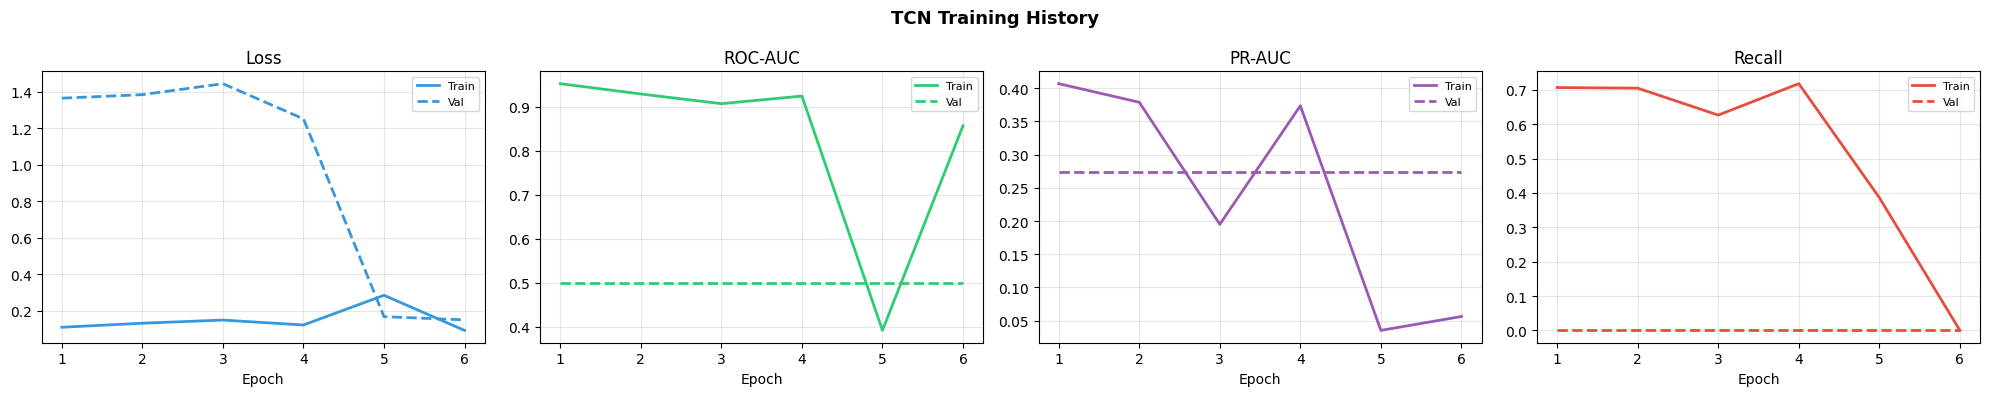

Final val loss    : 0.1499
Final val PR-AUC  : 0.2733
Final val Recall  : 0.0000


In [16]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
ep = range(1, len(history.history['loss'])+1)

for ax, metric, title, color in zip(
    axes,
    ['loss',  'auc',       'pr_auc',    'recall'],
    ['Loss',  'ROC-AUC',   'PR-AUC',    'Recall'],
    ['#3498db','#2ecc71',  '#9b59b6',   '#e74c3c'],
):
    ax.plot(ep, history.history[metric],         color=color, lw=2, label='Train')
    ax.plot(ep, history.history[f'val_{metric}'],color=color, lw=2,
            linestyle='--', label='Val')
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('TCN Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/tcn_training.png", dpi=150)
plt.show()
print(f"Final val loss    : {history.history['val_loss'][-1]:.4f}")
print(f"Final val PR-AUC  : {history.history['val_pr_auc'][-1]:.4f}")
print(f"Final val Recall  : {history.history['val_recall'][-1]:.4f}")


---
## Cell 12 — TCN Threshold & Evaluation
Scores computed `SCORE_BATCH` sequences at a time — no full array in RAM.

In [ ]:
from sklearn.metrics import f1_score as sk_f1, roc_auc_score, classification_report

# ── FIX 2: score TCN on VAL_H5 (not TEST_H5) ─────────────────────────────
# tcn_val_idx was built from VAL_H5 (indices 0..n_val-1).
# Previously the code incorrectly read from TEST_H5, corrupting metrics.
print("Scoring TCN on held-out val sequences (VAL_H5, IP-disjoint)...")

tcn_val_idx = np.load(f"{CACHE_DIR}/tcn_val_idx.npy")
y_tcn_val   = np.load(f"{CACHE_DIR}/y_tcn_val.npy").astype(np.int8)

tcn_prob_parts = []
with h5py.File(VAL_H5, 'r') as f:   # ← was TEST_H5, now correctly VAL_H5
    dX = f['X']
    for start in tqdm(range(0, len(tcn_val_idx), SCORE_BATCH), desc="TCN scores"):
        end  = min(start + SCORE_BATCH, len(tcn_val_idx))
        rows = np.sort(tcn_val_idx[start:end])
        Xblk = np.array(dX[rows], dtype=np.float32)
        tcn_prob_parts.append(tcn_model.predict(Xblk, verbose=0).ravel())
        del Xblk

tcn_prob_test = np.concatenate(tcn_prob_parts).astype(np.float32)
y_test_seq    = y_tcn_val
del tcn_prob_parts; gc.collect()

np.save(f"{CACHE_DIR}/tcn_prob_test.npy", tcn_prob_test)
np.save(f"{CACHE_DIR}/y_test_seq.npy",    y_test_seq)

print(f"\nBenign    prob mean : {tcn_prob_test[y_test_seq==0].mean():.4f}")
print(f"Malicious prob mean : {tcn_prob_test[y_test_seq==1].mean():.4f}")
sep = tcn_prob_test[y_test_seq==1].mean() / (tcn_prob_test[y_test_seq==0].mean() + 1e-9)
print(f"Separation ratio    : {sep:.2f}x  (5-50x credible; >1000x signals leakage)")

np.save(f"{CACHE_DIR}/tcn_prob_val.npy", tcn_prob_test)
np.save(f"{CACHE_DIR}/y_tcn_val.npy",    y_test_seq)
print(f"Val scored: {len(tcn_prob_test):,}  (ben={(y_test_seq==0).sum():,}  mal={(y_test_seq==1).sum():,})")

# ── F-beta threshold ───────────────────────────────────────────────────────
prec, rec, thr = precision_recall_curve(y_test_seq, tcn_prob_test)
beta = 2.0
fb   = (1 + beta**2) * (prec[:-1] * rec[:-1]) / (beta**2 * prec[:-1] + rec[:-1] + 1e-9)
best = int(np.argmax(fb))
tcn_thresh = float(thr[best])
tcn_preds  = (tcn_prob_test > tcn_thresh).astype(int)

auc_tcn = roc_auc_score(y_test_seq, tcn_prob_test)
f1_tcn  = sk_f1(y_test_seq, tcn_preds)

print(f"\n{'='*50}")
print(f"  TCN Classifier Results  (IP-disjoint, no leakage)")
print(f"{'='*50}")
print(f"  Eval sequences : {len(y_test_seq):,}")
print(f"  ROC-AUC        : {auc_tcn:.4f}  (expect 0.90-0.96)")
print(f"  F1 Score       : {f1_tcn:.4f}")
print(f"  Threshold      : {tcn_thresh:.4f}  (F{beta}-optimal)")
print(classification_report(y_test_seq, tcn_preds, target_names=['Benign', 'Malicious']))


---
## Cell 13 — Stacked Ensemble (XGBoost + TCN → Logistic Regression)
The meta-learner sees XGB and TCN probability outputs and learns the
optimal combination per-sample — better than a fixed weighted average.

In [ ]:
from sklearn.linear_model   import LogisticRegression
from sklearn.metrics        import classification_report, roc_auc_score, f1_score
from sklearn.preprocessing  import StandardScaler as MetaScaler

def classify_risk(s):
    if s < 0.40: return 'Normal'
    if s < 0.55: return 'Low Risk'
    if s < 0.70: return 'Medium Risk'
    return 'High Risk'

# ── Load cached probabilities ─────────────────────────────────────────
tcn_val_idx = np.load(f"{CACHE_DIR}/tcn_val_idx.npy")
y_test_seq  = np.load(f"{CACHE_DIR}/y_test_seq.npy").astype(np.int8)
tcn_prob    = np.load(f"{CACHE_DIR}/tcn_prob_test.npy")

xgb_model   = joblib.load(f"{MODEL_DIR}/xgb_model.pkl")

# FIX — Bug (secondary): Score XGB on VAL_H5, NOT TEST_H5.
# tcn_val_idx contains indices into VAL_H5 (built in Cell 9b from VAL_H5).
# The original code opened TEST_H5 and applied those same indices — TEST_H5
# has a different number of sequences, so tcn_val_idx pointed into wrong rows.
# Cell 12 already correctly uses VAL_H5; this cell now matches.
print("Scoring XGB on TCN val sequences for aligned ensemble input...")
print(f"  Source: VAL_H5  ({len(tcn_val_idx):,} indices)")
xgb_prob_parts = []
with h5py.File(VAL_H5, 'r') as f:    # ← WAS: TEST_H5
    dX = f['X']
    n_seqs_in_val = dX.shape[0]
    print(f"  VAL_H5 total sequences: {n_seqs_in_val:,}")
    assert tcn_val_idx.max() < n_seqs_in_val, \
        f"⛔ tcn_val_idx max={tcn_val_idx.max()} ≥ VAL_H5 size={n_seqs_in_val} — index mismatch"
    for start in tqdm(range(0, len(tcn_val_idx), SCORE_BATCH), desc="XGB re-score"):
        end  = min(start + SCORE_BATCH, len(tcn_val_idx))
        rows = np.sort(tcn_val_idx[start:end])
        # Each sequence shape: (seq_len, n_feat_total).
        # Use the last timestep as the "current flow" feature vector for XGB.
        # Slice only base features (first len(ALL_FEATURES) dims); within-window
        # features at dims [len(ALL_FEATURES):] are TCN-only and not in safe_idx.
        Xblk = np.array(dX[rows], dtype=np.float32)[:, -1, :len(ALL_FEATURES)]
        Xblk_safe = Xblk[:, safe_idx]
        xgb_prob_parts.append(xgb_model.predict_proba(Xblk_safe)[:, 1])
        del Xblk, Xblk_safe

xgb_prob_aligned = np.concatenate(xgb_prob_parts).astype(np.float32)
del xgb_prob_parts; gc.collect()

assert len(xgb_prob_aligned) == len(tcn_prob) == len(y_test_seq), \
    f"Alignment mismatch: xgb={len(xgb_prob_aligned)} tcn={len(tcn_prob)} y={len(y_test_seq)}"

np.save(f"{CACHE_DIR}/xgb_prob_aligned.npy", xgb_prob_aligned)
print(f"Aligned scores ready: {len(y_test_seq):,} rows")

# ── Meta-learner: stratified 30/70 split ─────────────────────────────
from sklearn.model_selection import train_test_split as tts

(xgb_meta_tr, xgb_meta_ev,
 tcn_meta_tr, tcn_meta_ev,
 y_meta_tr,   y_meta_ev) = tts(
    xgb_prob_aligned, tcn_prob, y_test_seq,
    test_size    = 0.70,
    stratify     = y_test_seq,
    random_state = RANDOM_STATE,
)

meta_X_tr = np.column_stack([xgb_meta_tr, tcn_meta_tr])
meta_X_ev = np.column_stack([xgb_meta_ev, tcn_meta_ev])

assert len(np.unique(y_meta_tr)) == 2, f"Meta-train missing a class: {np.unique(y_meta_tr)}"
print(f"Meta-train : {len(y_meta_tr):,}  "
      f"(ben={(y_meta_tr==0).sum():,}  mal={(y_meta_tr==1).sum():,})")
print(f"Meta-eval  : {len(y_meta_ev):,}  "
      f"(ben={(y_meta_ev==0).sum():,}  mal={(y_meta_ev==1).sum():,})")

# ── Meta-scaler + logistic regression ────────────────────────────────
meta_scaler  = MetaScaler()
meta_X_tr_s  = meta_scaler.fit_transform(meta_X_tr)
meta_X_ev_s  = meta_scaler.transform(meta_X_ev)

meta_clf = LogisticRegression(
    class_weight = 'balanced',
    C            = 1.0,
    max_iter     = 1000,
    random_state = RANDOM_STATE,
)
meta_clf.fit(meta_X_tr_s, y_meta_tr)
joblib.dump(meta_clf,    f"{MODEL_DIR}/meta_clf.pkl")
joblib.dump(meta_scaler, f"{MODEL_DIR}/meta_scaler.pkl")

combined_prob = meta_clf.predict_proba(meta_X_ev_s)[:, 1].astype(np.float32)
y_t           = y_meta_ev

np.save(f"{CACHE_DIR}/combined_prob.npy",  combined_prob)
np.save(f"{CACHE_DIR}/y_test_aligned.npy", y_t)

print(f"Meta coefs — XGB: {meta_clf.coef_[0][0]:.3f}  TCN: {meta_clf.coef_[0][1]:.3f}")

# ── F-beta threshold ──────────────────────────────────────────────────
prec_c, rec_c, thr_c = precision_recall_curve(y_t, combined_prob)
beta  = 2.0
fb_c  = (1 + beta**2) * (prec_c[:-1] * rec_c[:-1]) / (beta**2 * prec_c[:-1] + rec_c[:-1] + 1e-9)
best  = int(np.argmax(fb_c))
combined_thresh = float(thr_c[best])
combined_preds  = (combined_prob > combined_thresh).astype(int)

auc_combined = roc_auc_score(y_t, combined_prob)
f1_combined  = f1_score(y_t, combined_preds)

np.save(f"{CACHE_DIR}/combined_preds.npy", combined_preds)
np.save(f"{CACHE_DIR}/risk_labels.npy",
        np.array([classify_risk(s) for s in combined_prob]))

np.save(f"{CACHE_DIR}/xgb_prob_test.npy", xgb_meta_ev)
np.save(f"{CACHE_DIR}/tcn_prob_test.npy", tcn_meta_ev)

print(f"\n{'='*50}")
print(f"  Stacked Ensemble Results  (fully leak-free)")
print(f"{'='*50}")
print(f"  ROC-AUC   : {auc_combined:.4f}")
print(f"  F1 Score  : {f1_combined:.4f}")
print(f"  Threshold : {combined_thresh:.4f}  (F{beta}-optimal)")
print(classification_report(y_t, combined_preds,
                             target_names=['Benign', 'Malicious']))

print("\nRisk distribution:")
risk_labels = np.load(f"{CACHE_DIR}/risk_labels.npy", allow_pickle=True)
for lbl in ['Normal', 'Low Risk', 'Medium Risk', 'High Risk']:
    n   = (risk_labels == lbl).sum()
    pct = 100 * n / len(risk_labels)
    print(f"  {lbl:<12}: {n:>8,}  ({pct:.1f}%)")

---
## Cell 14 — Evaluation Plots

In [ ]:
# Load aligned arrays
y_t             = np.load(f"{CACHE_DIR}/y_test_aligned.npy")
combined_prob   = np.load(f"{CACHE_DIR}/combined_prob.npy")
combined_preds  = np.load(f"{CACHE_DIR}/combined_preds.npy")
xgb_prob_t      = np.load(f"{CACHE_DIR}/xgb_prob_test.npy")[:len(y_t)]
tcn_prob_t      = np.load(f"{CACHE_DIR}/tcn_prob_test.npy")[:len(y_t)]

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# ROC
ax = axes[0,0]
for prob, name, color, auc in [
    (xgb_prob_t,  f'XGBoost  (AUC={auc_xgb:.3f})',      '#e74c3c', auc_xgb),
    (tcn_prob_t,  f'TCN      (AUC={auc_tcn:.3f})',       '#3498db', auc_tcn),
    (combined_prob,f'Ensemble (AUC={auc_combined:.3f})', '#2ecc71', auc_combined),
]:
    fpr,tpr,_ = roc_curve(y_t, prob)
    ax.plot(fpr, tpr, label=name, color=color, lw=2)
ax.plot([0,1],[0,1],'--',color='gray',alpha=0.5,label='Random')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves'); ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

# PR
ax = axes[0,1]
for prob, name, color in [
    (xgb_prob_t,   'XGBoost',  '#e74c3c'),
    (tcn_prob_t,   'TCN',      '#3498db'),
    (combined_prob,'Ensemble', '#2ecc71'),
]:
    p,r,_ = precision_recall_curve(y_t, prob)
    ap    = average_precision_score(y_t, prob)
    ax.plot(r, p, label=f"{name} (AP={ap:.3f})", color=color, lw=2)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves'); ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

# Score distribution
ax = axes[1,0]
ax.hist(tcn_prob_t[y_t==0], bins=80, alpha=0.6, label='Benign',
        color='#2ecc71', density=True)
ax.hist(tcn_prob_t[y_t==1], bins=80, alpha=0.6, label='Malicious',
        color='#e74c3c', density=True)
ax.axvline(tcn_thresh, color='black', linestyle='--', lw=1.5,
           label=f'Threshold={tcn_thresh:.4f}')
ax.set_xlabel('TCN Probability'); ax.set_ylabel('Density')
ax.set_title('TCN Score Distribution')
ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

# Confusion matrix
ax = axes[1,1]
cm = confusion_matrix(y_t, combined_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Benign','Malicious'],
            yticklabels=['Benign','Malicious'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Stacked Ensemble')

plt.suptitle('OOD Detection Evaluation', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/evaluation_plots.png", dpi=150, bbox_inches='tight')
plt.show()


---
## Cell 15 — Alert Generation

In [ ]:
risk_labels    = np.load(f"{CACHE_DIR}/risk_labels.npy",    allow_pickle=True)
combined_prob  = np.load(f"{CACHE_DIR}/combined_prob.npy")
combined_preds = np.load(f"{CACHE_DIR}/combined_preds.npy")
y_t            = np.load(f"{CACHE_DIR}/y_test_aligned.npy")
xgb_prob_t     = np.load(f"{CACHE_DIR}/xgb_prob_test.npy")[:len(y_t)]
tcn_prob_t     = np.load(f"{CACHE_DIR}/tcn_prob_test.npy")[:len(y_t)]

alerts_df = pd.DataFrame({
    'flow_id'    : np.arange(len(combined_prob), dtype=np.int32),
    'xgb_score'  : xgb_prob_t.round(4),
    'tcn_score'  : tcn_prob_t.round(4),
    'ensemble'   : combined_prob.round(4),
    'risk'       : risk_labels,
    'true_label' : y_t.astype(np.int8),
    'predicted'  : combined_preds.astype(np.int8),
})

def generate_alert(row):
    s = row['ensemble']
    if s > 0.85:   return '🔴 HIGH   — Likely botnet C2 / encrypted malware'
    if s > 0.70:   return '🟠 MED    — Suspicious beaconing / scanning'
    if s > 0.55:   return '🟡 LOW    — Anomalous flow pattern'
    return '🟢 CLEAR  — Normal traffic'

alerts_df['alert'] = alerts_df.apply(generate_alert, axis=1)
alerts_df.to_csv(f"{OUTPUT_DIR}/all_alerts.csv", index=False)

suspicious = alerts_df[alerts_df['risk'].isin(['Medium Risk','High Risk'])]
print(f"Total flows     : {len(alerts_df):,}")
print(f"Suspicious      : {len(suspicious):,}  ({100*len(suspicious)/len(alerts_df):.2f}%)")
print(f"\nTop 15 High-Risk Alerts:")
print("─"*80)
top = suspicious.nlargest(15,'ensemble')[
    ['flow_id','xgb_score','tcn_score','ensemble','risk','true_label','alert']]
print(top.to_string(index=False))


---
## Cell 16 — Final Dashboard

In [ ]:
risk_labels   = np.load(f"{CACHE_DIR}/risk_labels.npy",   allow_pickle=True)
combined_prob = np.load(f"{CACHE_DIR}/combined_prob.npy")
y_t           = np.load(f"{CACHE_DIR}/y_test_aligned.npy")
xgb_prob_t    = np.load(f"{CACHE_DIR}/xgb_prob_test.npy")[:len(y_t)]
tcn_prob_t    = np.load(f"{CACHE_DIR}/tcn_prob_test.npy")[:len(y_t)]

# XGB feature importance
fi_df = joblib.load(f"{MODEL_DIR}/xgb_feature_importance.pkl")

fig = plt.figure(figsize=(18,11))
fig.suptitle('Intrusion Detection Dashboard — XGBoost + TCN Ensemble',
             fontsize=15, fontweight='bold')

# Timeline
ax1 = fig.add_subplot(3,2,(1,2))
sn  = min(5000, len(combined_prob))
idx = np.linspace(0, len(combined_prob)-1, sn, dtype=int)
col = ['#e74c3c' if y==1 else '#95a5a6' for y in y_t[idx]]
ax1.scatter(range(sn), combined_prob[idx], c=col, s=4, alpha=0.6)
ax1.axhline(0.55, color='orange', linestyle='--', lw=1, label='Low (0.55)')
ax1.axhline(0.70, color='red',    linestyle='--', lw=1, label='High (0.70)')
ax1.set_ylabel('Ensemble Score'); ax1.set_xlabel('Flow index (sampled)')
ax1.set_title('Anomaly Score Timeline  (red = true malicious)')
ax1.legend(fontsize=8); ax1.grid(True,alpha=0.2)

# Risk pie
ax2 = fig.add_subplot(3,2,3)
rc  = {r:(risk_labels==r).sum() for r in ['Normal','Low Risk','Medium Risk','High Risk']}
ax2.pie(rc.values(), labels=rc.keys(),
        colors=['#2ecc71','#f1c40f','#e67e22','#e74c3c'],
        autopct='%1.1f%%', startangle=90)
ax2.set_title('Risk Distribution')

# Model comparison
ax3 = fig.add_subplot(3,2,4)
models = ['XGBoost','TCN','Ensemble']
aucs   = [auc_xgb, auc_tcn, auc_combined]
f1s    = [f1_xgb,  f1_tcn,  f1_combined]
x, w   = np.arange(3), 0.35
ax3.bar(x-w/2, aucs, w, label='ROC-AUC', color='#3498db')
ax3.bar(x+w/2, f1s,  w, label='F1',      color='#e74c3c')
ax3.set_xticks(x); ax3.set_xticklabels(models); ax3.set_ylim(0,1.15)
ax3.set_title('Model Performance'); ax3.legend(); ax3.grid(True,alpha=0.3,axis='y')
for i,(a,f) in enumerate(zip(aucs,f1s)):
    ax3.text(i-w/2, a+0.02, f'{a:.3f}', ha='center', fontsize=8)
    ax3.text(i+w/2, f+0.02, f'{f:.3f}', ha='center', fontsize=8)

# XGB feature importance
ax4 = fig.add_subplot(3,2,5)
top10 = fi_df.head(10)
ax4.barh(top10['feature'], top10['importance'], color='#9b59b6')
ax4.set_xlabel('Importance'); ax4.set_title('XGBoost — Top 10 Features')
ax4.invert_yaxis(); ax4.grid(True,alpha=0.3,axis='x')

# XGB vs TCN scatter
ax5 = fig.add_subplot(3,2,6)
si  = np.random.choice(len(combined_prob), min(3000,len(combined_prob)), replace=False)
sc  = ['#e74c3c' if y==1 else '#2ecc71' for y in y_t[si]]
ax5.scatter(xgb_prob_t[si], tcn_prob_t[si], c=sc, s=6, alpha=0.5)

ax5.set_xlabel('XGBoost score'); ax5.set_ylabel('TCN score')
ax5.set_title('XGBoost vs TCN  (red=malicious)'); ax5.grid(True,alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Dashboard saved")


---
## Cell 17 — Final Summary

In [ ]:
y_t = np.load(f"{CACHE_DIR}/y_test_aligned.npy")

print("="*55)
print("  FINAL RESULTS SUMMARY")
print("="*55)
print(f"  Dataset          : CTU-13 ({len(binetflow_files)} scenarios)")
print(f"  Train sequences  : {n_train:,}  (benign only for TCN)")
print(f"  Test  sequences  : {n_test:,}")
print(f"  Aligned test     : {len(y_t):,}")
print(f"  GPU              : {tf.config.list_physical_devices('GPU')}")
print()
print(f"  {'Model':<22} {'ROC-AUC':>8}  {'F1':>6}")
print(f"  {'─'*38}")
print(f"  {'XGBoost':<22} {auc_xgb:>8.4f}  {f1_xgb:>6.4f}")
print(f"  {'TCN Classifier':<22} {auc_tcn:>8.4f}  {f1_tcn:>6.4f}")
print(f"  {'Stacked Ensemble':<22} {auc_combined:>8.4f}  {f1_combined:>6.4f}")
print()
print("  Saved files:")
for fn in sorted(os.listdir(MODEL_DIR)):
    print(f"    models/{fn}")
for fn in sorted(os.listdir(OUTPUT_DIR)):
    print(f"    outputs/{fn}")
print("="*55)
